trees=60: 32.4s
trees=100: 38.2s
trees=500: 41.2s
trees=1000: 53.5s


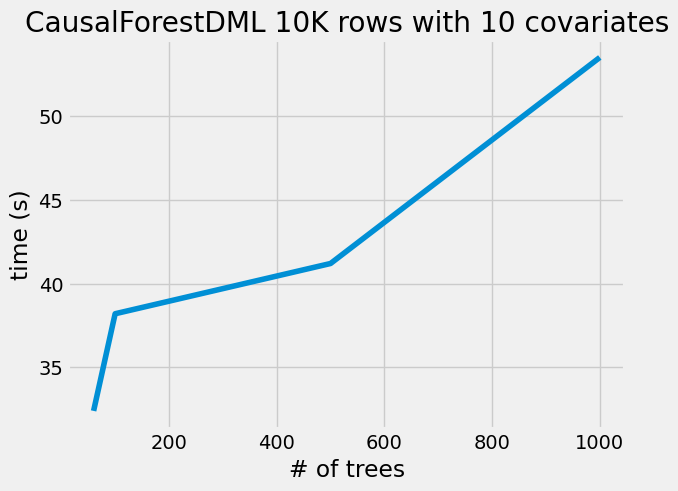

In [12]:
import time
import pandas as pd
import numpy as np

np.random.seed(42)
from econml.dml import CausalForestDML

from causalml.dataset import synthetic_data

import matplotlib.pyplot as plt
import seaborn as sns

df_times = pd.DataFrame(columns=['trees', 'time'])
Y, X, T, _, _, _ = synthetic_data(mode=2, n=10000, p=10, sigma=3.0) # Simulate randomized trial: mode=2

for n in (60, 100, 500, 1000):

    start = time.time()
    est = CausalForestDML(n_estimators=n, discrete_treatment=True)
    est.fit(Y=Y, T=T, X=X, inference="blb")
    end = time.time()
    
    t = round(end - start,1)
    print(f"trees={n}: {t}s")
    df_times.loc[-1] = [n ,t]  # adding a row
    df_times.index = df_times.index + 1 


g = sns.lineplot(data=df_times, x='trees', y='time')
plt.ylabel('time (s)')
plt.xlabel('# of trees')
plt.title("CausalForestDML 10K rows with 10 covariates")
plt.show()